In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [14]:
DISTRICT_POP = {"kasungu":  842953 , "mchinji": 602305, "dowa": 772569, "all": 1579995 }

def plot_policy_analysis(district):
    
    CONVERSION_FACTOR = DISTRICT_POP[district] * 148.83
    # Read the CSV file into a DataFrame
    df = pd.read_csv("results/{}_pool=central.csv".format(district))

    # Sort the DataFrame by "unconditional_tolerance"
    df_sorted = df.sort_values(by='unconditional_tolerance')

    # Group the data by policy type
    grouped = df_sorted.groupby('policy')

    # Determine the minimum and maximum values of the x-axis
    x_min = min(df['unconditional_tolerance'].min(), df['post_transfer_poverty_rate'].min()) - 0.02
    x_max = max(df['unconditional_tolerance'].max(), df['post_transfer_poverty_rate'].max()) + 0.02

    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Plot policy_cost vs. tolerance for each policy type
    for name, group in grouped:
            axs[0].plot(group['unconditional_tolerance'], group['policy_cost'] * CONVERSION_FACTOR, marker='o', label=name)
    axs[0].set_xlabel('Unconditional Tolerance')
    axs[0].set_ylabel('Policy Cost')
    axs[0].set_title('Policy Cost vs. Unconditional Tolerance')
    axs[0].legend()
    axs[0].set_xlim(x_min, x_max)

    # Plot policy_cost vs. post_transfer_poverty_rate by policy type
    for name, group in grouped:
            axs[1].plot(group['post_transfer_poverty_rate'], group['policy_cost']* CONVERSION_FACTOR, marker='o', label=name)

    # Add labels and title
    axs[1].set_xlabel('Post-Transfer Poverty Rate')
    axs[1].set_ylabel('Policy Cost')
    axs[1].set_title('Policy Cost vs. Post-Transfer Poverty Rate')
    axs[1].legend()
    axs[1].set_xlim(x_min, x_max)

        # Plot post_transfer_poverty_rate vs. tolerance for each policy type
    for name, group in grouped:
            axs[2].plot(group['unconditional_tolerance'], group['post_transfer_poverty_rate'], marker='o', label=name)

    axs[2].plot(group["unconditional_tolerance"], group["unconditional_tolerance"], color='black', linestyle='--')

    axs[2].set_xlabel('Unconditional Tolerance')
    axs[2].set_ylabel('Post-Transfer Poverty Rate')
    axs[2].set_title('Post-Transfer Poverty Rate vs. Unconditional Tolerance')
    axs[2].legend()

    plt.suptitle("Malawi District: {}".format(district))
    # Display the plot
    plt.tight_layout()
    plt.savefig("figs/{}.pdf".format(district))
    plt.show()

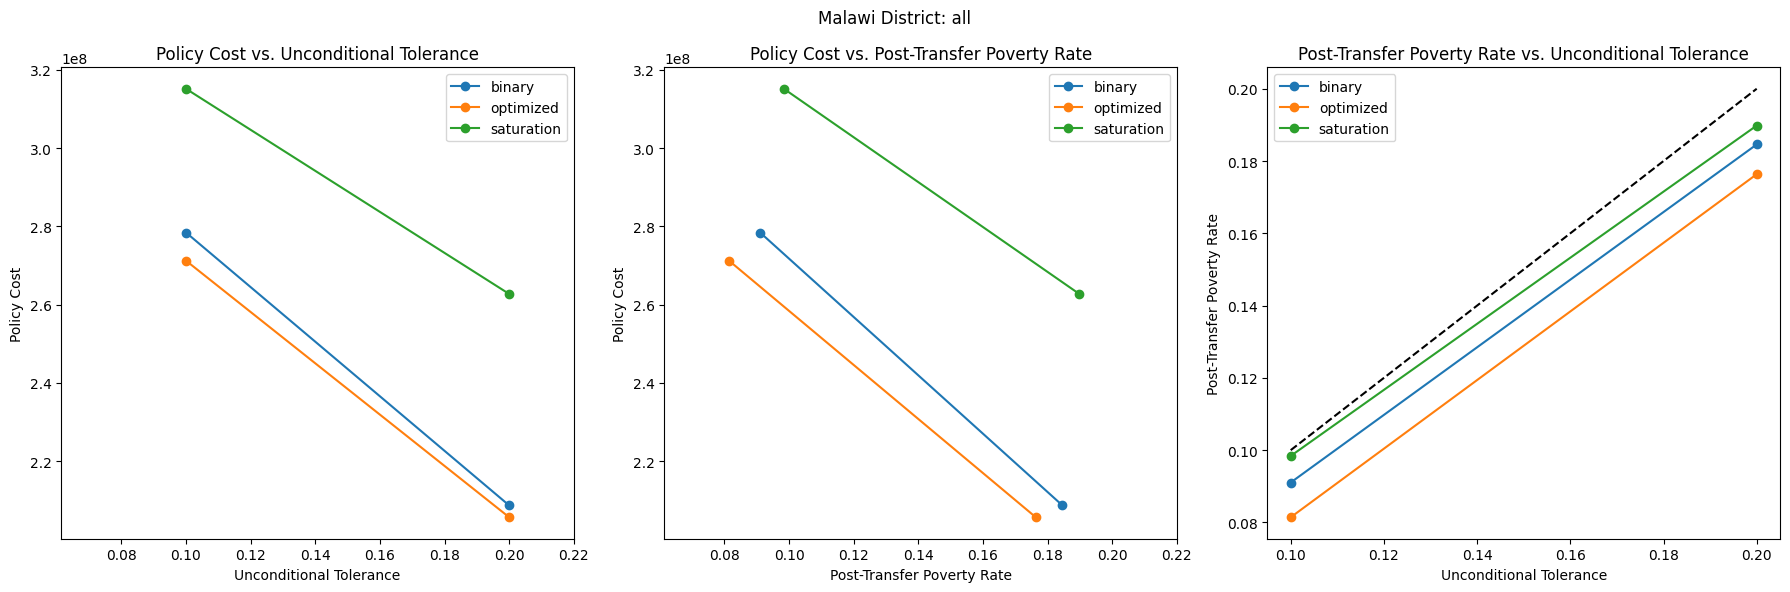

In [16]:
for district in ["all"]:
        plot_policy_analysis(district)